<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 175 &middot; Capstone 16 &middot; Kruskal-Wallis</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Which Store Is Letting Us Down?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">Four locations, 194 customer ratings, and skewed ordinal scores that break every ANOVA assumption. The omnibus test answers "do they differ". Only the follow-up answers "which", and the answer refuses to line up in a neat order.</div>
</div>

In [1]:
import subprocess, sys
try:
    import scikit_posthocs as sp
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-posthocs"], check=False)
    import scikit_posthocs as sp

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-store-ratings-across-locations.xlsx"
try:
    raw = pd.read_excel("../../data/" + fn, sheet_name="feedback")
except FileNotFoundError:
    raw = pd.read_excel(BASE + fn, sheet_name="feedback")
print("loaded", raw.shape[0], "responses")
raw.head()

loaded 201 responses


,response_id,location,rating,months_as_customer
0,F7060,Northgate,6.0,3
1,F7006,Riverside,10.0,4
2,F7021,Riverside,6.0,8
3,F7193,Harbour Point,3.0,2
4,F7053,Northgate,6.0,8


## Step 1 &middot; Goal and hypotheses
Four store locations collected customer experience ratings over one quarter. The regional manager wants to know whether the locations really differ, and if so, which ones need attention.

- **H&#8320; (null):** the four locations' rating distributions are the same. A customer is equally likely to rate highly wherever they shopped.
- **H&#8321; (alternative):** at least one location differs from the others.
- **&#945; = 0.05.**

The alternative says **at least one**, which is all an omnibus test can deliver. Pinning down *which* locations differ is a separate step with its own error-rate problem, and Step 8 handles it.

## Step 2 &middot; Classify the data
The outcome is a 1-to-10 experience rating: **ordinal**, bounded, and, as it turns out, piled up near the top. The grouping variable is **nominal** with four levels. Group sizes differ because each store collected what it could, which is untidy but perfectly acceptable for the methods used here.

## Step 3 &middot; Prepare and clean
Valid ratings run 1 to 10. Location labels arrive with inconsistent casing.

In [2]:
before = len(raw)
df = raw.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["rating"]); a_na = len(df)
df["location"] = df.location.str.strip().str.title()
bad = df[~df.rating.between(1,10)]
df = df[df.rating.between(1,10)].copy()
df["rating"] = df.rating.astype(int)
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})  ->  dropna {a_na} (-{a_dup-a_na})")
print("out-of-range ratings removed:", bad.rating.tolist())
print("locations after normalizing labels:", sorted(df.location.unique()))
print(f"\nclean analysis sample: n = {len(df)}\n")
print(df.groupby("location").rating.agg(["count","median","mean","std"]).round(2).to_string())

start 201  ->  dedup 198 (-3)  ->  dropna 195 (-3)
out-of-range ratings removed: [11.0]
locations after normalizing labels: ['Harbour Point', 'Northgate', 'Old Town', 'Riverside']

clean analysis sample: n = 194

               count  median  mean   std
location                                
Harbour Point     43     6.0  5.63  2.24
Northgate         57     7.0  6.79  1.74
Old Town          48     7.0  7.42  1.37
Riverside         46     8.0  7.96  1.33


## Step 4 &middot; Explore before testing

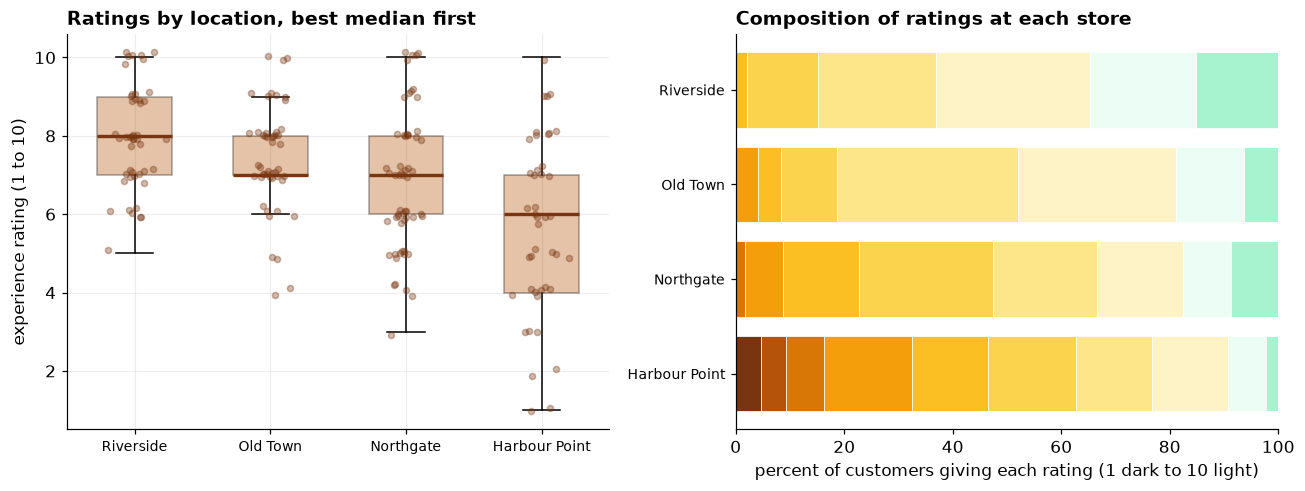

Riverside       n =  46   median 8.0   IQR 7 to 9   mean 7.96
Old Town        n =  48   median 7.0   IQR 7 to 8   mean 7.42
Northgate       n =  57   median 7.0   IQR 6 to 8   mean 6.79
Harbour Point   n =  43   median 6.0   IQR 4 to 7   mean 5.63


In [3]:
LOC = ["Riverside","Old Town","Northgate","Harbour Point"]   # ordered by median, best first
groups = [df[df.location==l].rating.values.astype(float) for l in LOC]
rng = np.random.default_rng(3)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
ax = axes[0]
bp = ax.boxplot(groups, patch_artist=True, widths=0.55, tick_labels=LOC, showfliers=False)
for patch in bp["boxes"]: patch.set_facecolor(GOLD); patch.set_alpha(0.35)
for med in bp["medians"]: med.set_color(DARK); med.set_linewidth(2.2)
for i, g in enumerate(groups, start=1):
    ax.scatter(rng.normal(i, 0.07, len(g)), g + rng.normal(0, 0.10, len(g)),
               s=16, color=DARK, alpha=0.35, zorder=3)
ax.set_ylabel("experience rating (1 to 10)"); ax.set_title("Ratings by location, best median first")
ax.tick_params(axis="x", labelsize=9)

ax = axes[1]
levels = np.arange(1,11)
bottom = np.zeros(len(LOC))
shades = ["#78350f","#b45309","#d97706","#f59e0b","#fbbf24","#fcd34d","#fde68a","#fef3c7","#ecfdf5","#a7f3d0"]
for v, col in zip(levels, shades):
    share = np.array([(g==v).mean()*100 for g in groups])
    ax.barh(np.arange(len(LOC)), share, left=bottom, color=col, edgecolor="white", linewidth=0.5)
    bottom += share
ax.set_yticks(np.arange(len(LOC))); ax.set_yticklabels(LOC, fontsize=9); ax.invert_yaxis()
ax.set_xlabel("percent of customers giving each rating (1 dark to 10 light)")
ax.set_title("Composition of ratings at each store"); ax.grid(alpha=0); ax.set_xlim(0,100)
plt.tight_layout(); plt.show()

for l, g in zip(LOC, groups):
    print(f"{l:15s} n = {len(g):3d}   median {np.median(g):.1f}   IQR {np.percentile(g,25):.0f} to {np.percentile(g,75):.0f}   mean {g.mean():.2f}")

**What the exploration shows.** Riverside sits highest and Harbour Point lowest, with Old Town and Northgate in between and heavily overlapping. Notice the spreads: Harbour Point's ratings are not just lower, they are far more scattered, reaching well down the scale in a way no other store's do. Notice too that **Old Town and Northgate share a median of 7**, which will matter shortly.

## Step 5 &middot; Check the ANOVA assumptions
One-way ANOVA would be the obvious first thought with four groups. Check what it needs.

In [4]:
print(f"{'location':16s} {'n':>4s} {'Shapiro W':>10s} {'p':>10s} {'skew':>7s} {'SD':>6s}")
print("-"*60)
for l, g in zip(LOC, groups):
    sw = stats.shapiro(g)
    print(f"{l:16s} {len(g):4d} {sw.statistic:10.4f} {sw.pvalue:10.4f} {stats.skew(g):+7.2f} {g.std(ddof=1):6.2f}")
lev = stats.levene(*groups); bar = stats.bartlett(*groups)
print(f"\nLevene   (equal spread across the four) p = {lev.pvalue:.4f}")
print(f"Bartlett (equal spread across the four) p = {bar.pvalue:.2e}")
print(f"SD ratio, largest to smallest: {max(g.std(ddof=1) for g in groups)/min(g.std(ddof=1) for g in groups):.2f}x")

location            n  Shapiro W          p    skew     SD
------------------------------------------------------------
Riverside          46     0.9311     0.0092   -0.09   1.33
Old Town           48     0.9324     0.0084   -0.38   1.37
Northgate          57     0.9561     0.0373   +0.14   1.74
Harbour Point      43     0.9705     0.3302   -0.18   2.24

Levene   (equal spread across the four) p = 0.0012
Bartlett (equal spread across the four) p = 1.11e-03
SD ratio, largest to smallest: 1.68x


**What the checks said.** Normality is rejected in three of the four locations. No single store looks wildly non-normal, but with ratings bunched in the upper half of a bounded 10-point scale the departures are systematic rather than accidental. Equal spread is rejected as well, with Harbour Point close to 1.7 times as variable as the tightest store. Neither ANOVA assumption holds, and the underlying variable is ordinal in any case.

## Step 6 &middot; Choose the test
The **Kruskal-Wallis test** is the rank-based counterpart of one-way ANOVA. It pools every rating, replaces the values with their ranks across the whole sample, and asks whether the average rank differs between groups more than chance would allow. It handles unequal group sizes without adjustment, needs no distributional assumption, and works with ordinal data because it uses only the ordering.

## Step 7 &middot; Run the omnibus test

In [5]:
H, p_h = stats.kruskal(*groups)
k = len(groups); Nn = sum(len(g) for g in groups)
eps2 = (H - k + 1) / (Nn - k)
df["rank_all"] = df.rating.rank()
mr = df.groupby("location").rank_all.mean().reindex(LOC)
print(f"Kruskal-Wallis H = {H:.3f}   df = {k-1}   p = {p_h:.3e}   N = {Nn}")
print(f"epsilon-squared = {eps2:.3f}  (share of rank variation explained by location)\n")
print("mean rank by location (higher = better ratings):")
for l in LOC:
    print(f"  {l:15s} {mr[l]:6.1f}")

Kruskal-Wallis H = 32.751   df = 3   p = 3.635e-07   N = 194
epsilon-squared = 0.157  (share of rank variation explained by location)

mean rank by location (higher = better ratings):
  Riverside        126.8
  Old Town         110.0
  Northgate         88.8
  Harbour Point     63.8


**Reading the omnibus result.** The four locations are not interchangeable (p = 0.00000036). Epsilon-squared of 0.157 says location accounts for around 16 percent of the variation in ranks, a moderate effect. What the test does **not** say is which stores differ, and it is tempting but wrong to read the mean-rank ordering as though the gaps between adjacent stores were all established.

## Step 8 &middot; Which locations actually differ?
Six pairwise comparisons follow from four groups, and running six tests at 0.05 apiece would inflate the false-positive rate to around 26 percent. **Dunn's test** is the standard follow-up: it compares mean ranks pairwise using the ranking from the full sample, and the p-values are then adjusted, here by Holm's method.

Dunn's test, Holm-adjusted p-values

               Riverside  Old Town  Northgate  Harbour Point
Riverside         1.0000    0.1401     0.0021         0.0000
Old Town          0.1401    1.0000     0.1007         0.0004
Northgate         0.0021    0.1007     1.0000         0.0762
Harbour Point     0.0000    0.0004     0.0762         1.0000

pairs, ordered by mean-rank gap:
  Riverside       vs Harbour Point    rank gap  +63.0   p = 4.69e-07   DIFFERENT
  Old Town        vs Harbour Point    rank gap  +46.2   p = 3.50e-04   DIFFERENT
  Riverside       vs Northgate        rank gap  +38.1   p = 2.08e-03   DIFFERENT
  Northgate       vs Harbour Point    rank gap  +25.0   p = 7.62e-02   not distinguishable
  Old Town        vs Northgate        rank gap  +21.2   p = 1.01e-01   not distinguishable
  Riverside       vs Old Town         rank gap  +16.8   p = 1.40e-01   not distinguishable


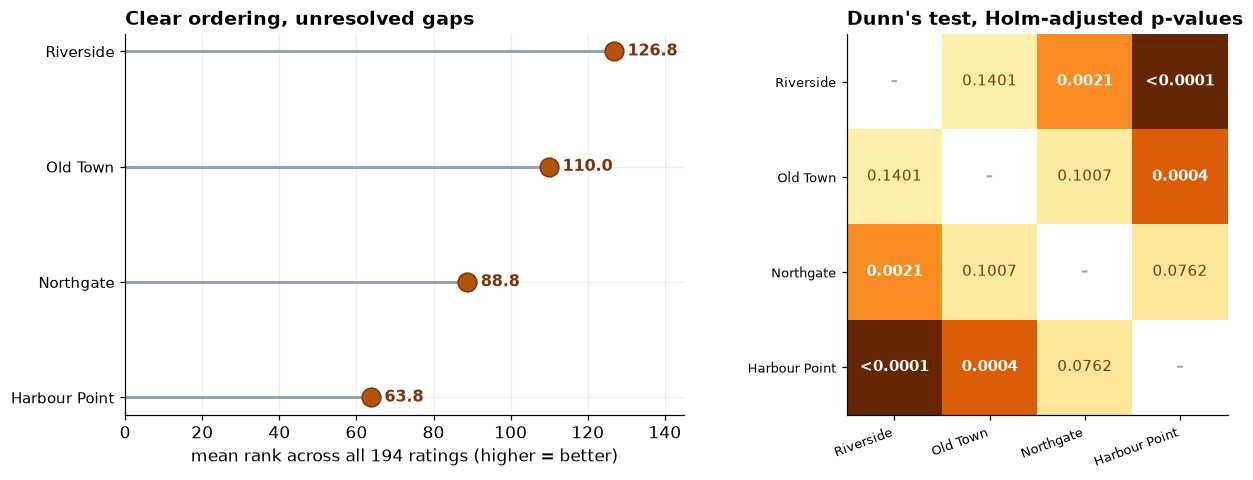

In [6]:
dunn = sp.posthoc_dunn(df, val_col="rating", group_col="location", p_adjust="holm")
dunn = dunn.reindex(index=LOC, columns=LOC)
print("Dunn's test, Holm-adjusted p-values\n")
print(dunn.round(4).to_string())
print("\npairs, ordered by mean-rank gap:")
pairs = [(a,b) for i,a in enumerate(LOC) for b in LOC[i+1:]]
rows = [(a, b, mr[a]-mr[b], dunn.loc[a,b]) for a,b in pairs]
for a, b, gap, pv in sorted(rows, key=lambda r: -abs(r[2])):
    flag = "DIFFERENT" if pv < 0.05 else "not distinguishable"
    print(f"  {a:15s} vs {b:15s}  rank gap {gap:+6.1f}   p = {pv:.2e}   {flag}")

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.5))
ax = axes[0]
ys = np.arange(len(LOC))[::-1]
ax.hlines(ys, 0, [mr[l] for l in LOC], color=MUT, lw=2)
ax.scatter([mr[l] for l in LOC], ys, s=150, color=GOLD, edgecolor=DARK, zorder=3)
for y, l in zip(ys, LOC):
    ax.text(mr[l] + 3.5, y, f"{mr[l]:.1f}", va="center", fontweight="bold", fontsize=10.5, color=DARK)
ax.set_yticks(ys); ax.set_yticklabels(LOC, fontsize=10)
ax.set_xlim(0, 145); ax.set_xlabel("mean rank across all 194 ratings (higher = better)")
ax.set_title("Clear ordering, unresolved gaps")

ax = axes[1]
M = dunn.values.astype(float).copy()
np.fill_diagonal(M, np.nan)
im = ax.imshow(np.log10(M), cmap="YlOrBr_r", vmin=-5, vmax=0)
for i in range(len(LOC)):
    for j in range(len(LOC)):
        if i == j:
            ax.text(j, i, "-", ha="center", va="center", color=MUT, fontsize=14)
        else:
            pv = M[i, j]
            ax.text(j, i, f"{pv:.4f}" if pv >= 0.0001 else "<0.0001", ha="center", va="center",
                    fontsize=9.5, fontweight="bold" if pv < 0.05 else "normal",
                    color=DARK if pv > 0.01 else "white")
ax.set_xticks(range(len(LOC))); ax.set_xticklabels(LOC, fontsize=8.5, rotation=20, ha="right")
ax.set_yticks(range(len(LOC))); ax.set_yticklabels(LOC, fontsize=8.5)
ax.set_title("Dunn's test, Holm-adjusted p-values"); ax.grid(alpha=0)
plt.tight_layout(); plt.show()

**The result that does not sort neatly.** Riverside beats Northgate and Harbour Point. Old Town beats Harbour Point. But **Old Town cannot be separated from either Riverside above it or Northgate below it**, and Northgate cannot be separated from Harbour Point despite a 25-point gap in mean rank. The ordering is real; the gaps between neighbors mostly are not resolvable at this sample size.

## Step 9 &middot; Two things worth noticing about this result

In [7]:
print("A. Northgate and Old Town have the SAME median:")
for l in ["Northgate","Old Town"]:
    g = df[df.location==l].rating.values
    print(f"   {l:12s} median {np.median(g):.1f}   mean rank {mr[l]:.1f}   share rating 8+ {(g>=8).mean()*100:.0f}%")
print("\n   Identical medians, mean ranks 21 apart. Kruskal-Wallis is not comparing medians.\n")
print("B. 'Significantly different' does not chain together:")
print(f"   Riverside vs Northgate      p = {dunn.loc['Riverside','Northgate']:.4f}  -> different")
print(f"   Riverside vs Old Town       p = {dunn.loc['Riverside','Old Town']:.4f}  -> not distinguishable")
print(f"   Old Town  vs Northgate      p = {dunn.loc['Old Town','Northgate']:.4f}  -> not distinguishable")
print("\n   Old Town sits between two stores that differ from each other, and differs from neither.")

A. Northgate and Old Town have the SAME median:
   Northgate    median 7.0   mean rank 88.8   share rating 8+ 33%
   Old Town     median 7.0   mean rank 110.0   share rating 8+ 48%

   Identical medians, mean ranks 21 apart. Kruskal-Wallis is not comparing medians.

B. 'Significantly different' does not chain together:
   Riverside vs Northgate      p = 0.0021  -> different
   Riverside vs Old Town       p = 0.1401  -> not distinguishable
   Old Town  vs Northgate      p = 0.1007  -> not distinguishable

   Old Town sits between two stores that differ from each other, and differs from neither.


**A. Kruskal-Wallis does not compare medians.** Northgate and Old Town both have a median of 7, and the test still separates them by 21 points of mean rank, because Old Town has far more customers up at 8 and above. Like Mann-Whitney in <a href="../chapters/capstone-pain-relief-two-treatments.html">Capstone 14</a>, this is a test of whether one group's values tend to be larger, not of any single summary statistic.

**B. Significance is not transitive.** Riverside differs from Northgate, yet Old Town, which sits between them, differs from neither. That is not a contradiction and it is not a flaw in Dunn's test. Failing to reject is not the same as establishing equality, and a middle group simply overlaps both of its neighbors enough that neither gap clears the bar. Any summary that sorts the stores into tidy tiers is inventing a precision the data do not have.

## Step 10 &middot; Estimate, do not just test
Three of the six comparisons came back "not distinguishable". That phrase does a lot of work and hides an important distinction, because a pair can be indistinguishable for two very different reasons: the stores really are alike, or the study was too small to tell. Intervals separate the two cases; p-values do not.

In [8]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

from statsmodels.stats.proportion import proportion_confint

# Effect size with an interval.
def eps_of(g):
    Hh = stats.kruskal(*g).statistic
    Nn_ = sum(len(x) for x in g)
    return (Hh - len(g) + 1) / (Nn_ - len(g))
e_lo, e_hi, _ = boot_ci_groups(groups, eps_of, B=3000, seed=16)
print(f"epsilon-squared {eps2:.3f}   95% CI [{e_lo:.3f}, {e_hi:.3f}]\n")

# A magnitude for each pair: the Hodges-Lehmann shift, with a bootstrap interval.
print(f"{'comparison':34s} {'HL shift':>9s}  {'95% CI':>16s}  {'Dunn p':>8s}")
print("-"*74)
gmap = dict(zip(LOC, groups))
for i_, A_ in enumerate(LOC):
    for B_ in LOC[i_+1:]:
        ga, gb = gmap[A_], gmap[B_]
        hl_ = np.median([u - v for u in ga for v in gb])
        l_, h_, _ = boot_ci_groups([ga, gb],
                    lambda g: np.median([u - v for u in g[0] for v in g[1]]), B=1200, seed=17)
        print(f"{A_+' vs '+B_:34s} {hl_:+9.1f}  [{l_:+5.1f}, {h_:+5.1f}]  {dunn.loc[A_,B_]:8.4f}")

# Top-box share by store, which is the reportable number for an ordinal scale.
print()
for l_, g in zip(LOC, groups):
    k_ = int((g >= 8).sum()); lo_, hi_ = proportion_confint(k_, len(g), method="wilson")
    print(f"{l_:14s} rating 8+  {k_:2d}/{len(g):2d} = {k_/len(g)*100:3.0f}%   95% CI [{lo_*100:3.0f}%, {hi_*100:3.0f}%]")

epsilon-squared 0.157   95% CI [0.074, 0.283]

comparison                          HL shift            95% CI    Dunn p
--------------------------------------------------------------------------
Riverside vs Old Town                   +1.0  [ +0.0,  +1.0]    0.1401


Riverside vs Northgate                  +1.0  [ +1.0,  +2.0]    0.0021
Riverside vs Harbour Point              +2.0  [ +1.0,  +3.0]    0.0000


Old Town vs Northgate                   +1.0  [ +0.0,  +1.0]    0.1007
Old Town vs Harbour Point               +2.0  [ +1.0,  +3.0]    0.0004


Northgate vs Harbour Point              +1.0  [ +0.0,  +2.0]    0.0762

Riverside      rating 8+  29/46 =  63%   95% CI [ 49%,  75%]
Old Town       rating 8+  23/48 =  48%   95% CI [ 34%,  62%]
Northgate      rating 8+  19/57 =  33%   95% CI [ 22%,  46%]
Harbour Point  rating 8+  10/43 =  23%   95% CI [ 13%,  38%]


**The shift estimates are coarse, and the reason is instructive.** Every Hodges-Lehmann shift comes out at a whole number of rating points, because the ratings themselves are whole numbers: the median of a set of integer differences is an integer or a half. On a 10-point scale a shift statistic simply cannot resolve anything finer, so it is a blunt instrument for separating the unresolved pairs. Notice, though, what the interval widths still tell you. Northgate against Harbour Point runs from 0 to 2 points, so that pair is *probably* different and this quarter could not confirm it. Riverside against Old Town runs from 0 to 1, a genuinely narrow gap. Both were reported as "p above 0.05"; they are not the same situation.

**The top-box shares are where the resolution actually is.** 63 percent of Riverside's customers rate 8 or above against 23 percent of Harbour Point's, and each share carries a margin of roughly 12 to 14 points. That is the comparison to put in front of an operations team, because it is expressed in customers rather than in ranks and it does not require averaging an ordinal scale.

**Epsilon-squared gets a range too**, roughly 0.07 to 0.28, so "location explains about a sixth of the variation" is a fair summary and anything more precise is not. The top-box shares are the numbers for a dashboard, with margins attached, and they carry the same warning as everywhere else in this part: an ordinal scale supports a share, not an average.

## Step 11 &middot; A confounder the file was carrying all along
Each response records `months_as_customer`. Stores in different neighborhoods attract different customers, and tenure is one of the few ways this dataset can show that.

In [9]:
d2 = df.dropna(subset=["months_as_customer"]).copy()
print("customer tenure by location")
print(d2.groupby("location").months_as_customer.agg(["count","mean","median"]).round(1).reindex(LOC).to_string())
kw_t = stats.kruskal(*[d2[d2.location == l].months_as_customer.values for l in LOC])
print(f"  tenure differs across locations: H = {kw_t.statistic:.2f}, p = {kw_t.pvalue:.4f}\n")

r_tr = stats.spearmanr(d2.months_as_customer.values.astype(float), d2.rating.values.astype(float))
print(f"tenure vs rating (all stores pooled): rho = {r_tr.statistic:+.3f}, p = {r_tr.pvalue:.3f}\n")
print("for a variable to confound the store comparison it must do BOTH:")
print("  (a) differ across stores, and  (b) relate to the rating.")
print(f"  (a) {'YES' if kw_t.pvalue < 0.05 else 'no'}   (b) {'YES' if r_tr.pvalue < 0.05 else 'no'}")

customer tenure by location
               count  mean  median
location                          
Riverside         46   6.9     8.0
Old Town          48   5.9     6.0
Northgate         57   6.4     7.0
Harbour Point     43   6.3     7.0
  tenure differs across locations: H = 2.12, p = 0.5479

tenure vs rating (all stores pooled): rho = +0.014, p = 0.845

for a variable to confound the store comparison it must do BOTH:
  (a) differ across stores, and  (b) relate to the rating.
  (a) no   (b) no


**The two conditions a confounder has to meet.** A variable can only distort the store comparison if it differs between stores *and* relates to the outcome. Tenure fails both tests here, so it is not quietly producing the ranking, and that is one alternative explanation retired.

The reasoning is the transferable part. Whenever a group comparison comes back significant, the question is not "could something else explain this?" in the abstract; it is which measured variable satisfies both conditions. Run that check on every covariate you have. Then say plainly that the ones you did not measure, catchment, store size, footfall, and staffing, are still open, because <strong>this is an observational comparison and no test in it was randomized</strong>. That is the difference between this chapter and <a href="../chapters/capstone-plant-growth-two-factors.html">Capstone 7</a>, which is the only study in the part that got to assign its conditions.

## Step 12 &middot; Interpret in plain language
Customer experience genuinely varies across the four locations, and about a sixth of the variation in ratings tracks with where the customer shopped. **Harbour Point is the clear problem**: lowest ratings, widest spread, and reliably below the two best stores. **Riverside is the strongest**. Old Town and Northgate sit in the middle and cannot be told apart from each other or, in Old Town's case, from Riverside.

The operational reading: put the attention on Harbour Point, keep an eye on Northgate, and do not build a ranking or a league table out of the middle two. The wide spread at Harbour Point is its own signal, suggesting an inconsistent experience rather than a uniformly poor one, which usually points at staffing or scheduling rather than at the site.

## Step 13 &middot; Ethics, bias, and limits
- **Customers who leave feedback are not customers.** Every rating here is volunteered, and people with strong feelings volunteer more readily. If Harbour Point's unhappy customers are also its most vocal, some of its gap is a response-rate artifact rather than a service difference.
- **The stores are not otherwise identical.** They serve different neighborhoods, sizes, and footfall patterns. This analysis compares locations, not management. Attributing the difference to the staff at Harbour Point requires evidence this design does not contain.
- **Ranking people on this would be a mistake.** A rating gap of the size found here, with the middle two stores indistinguishable, cannot support individual performance judgments. It supports a question worth asking at one location.
- **Do not average the ratings for a dashboard.** As in <a href="../chapters/capstone-satisfaction-and-loyalty.html">Capstone 12</a>, a mean of an ordinal scale assumes spacing the scale does not provide. The composition chart in Step 4 is the honest display.
- **Group sizes reflect collection effort, not population.** Northgate contributed the most responses because it collected the most, which is fine for these tests but means the pooled figures are not a picture of the customer base.

## Step 14 &middot; Where this test sits in the family
Kruskal-Wallis completes a set the earlier capstones started.

In [10]:
fam = pd.DataFrame({
    "design": ["two independent groups","two paired measurements","three or more independent groups",
               "three or more paired measurements"],
    "parametric": ["independent t-test","paired t-test","one-way ANOVA","repeated-measures ANOVA"],
    "rank-based": ["Mann-Whitney U","Wilcoxon signed-rank","Kruskal-Wallis","Friedman"],
    "capstone": ["14","15","16 (this one)","6 used the parametric route"],
})
print(fam.to_string(index=False))

                           design              parametric           rank-based                    capstone
           two independent groups      independent t-test       Mann-Whitney U                          14
          two paired measurements           paired t-test Wilcoxon signed-rank                          15
 three or more independent groups           one-way ANOVA       Kruskal-Wallis               16 (this one)
three or more paired measurements repeated-measures ANOVA             Friedman 6 used the parametric route


**The symmetry is worth committing to memory.** Every parametric comparison has a rank-based counterpart that asks the same structural question with weaker assumptions. Friedman is the one this part did not run: it is Kruskal-Wallis for repeated measures, and it would have been the fallback in <a href="../chapters/capstone-cognitive-training-over-time.html">Capstone 6</a> had the sphericity correction not been available.

---
**From analysis to report.** The notebook carries the evidence: the cleaning, the distribution and composition pictures, the failed ANOVA assumptions, the omnibus test with its effect size, Dunn's pairwise follow-up with Holm adjustment, and the two lessons the result quietly teaches about medians and transitivity. The written reports turn it into guidance a regional manager can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.